In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("data/05_flats_FeatureEngineered.csv")

In [3]:
df.shape

(2904, 50)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_sqm                2904 non-null   float64
 1   bedroom                 2904 non-null   float64
 2   bathroom                2904 non-null   float64
 3   balcony                 2904 non-null   float64
 4   addl_room               2904 non-null   float64
 5   sector                  2904 non-null   str    
 6   landmark_count          2904 non-null   float64
 7   has_hospital_or_clinic  2904 non-null   float64
 8   has_police_stn          2904 non-null   float64
 9   has_fire_stn            2904 non-null   float64
 10  has_mall                2904 non-null   float64
 11  has_market              2904 non-null   float64
 12  has_park                2904 non-null   float64
 13  has_bank_or_atm         2904 non-null   float64
 14  has_institute           2904 non-null   float64
 15

In [5]:
df.head(2)

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,stove,tv,washing machine,water purifier,area_type,floor_rise,age,society,city,price_cr
0,83.61,2.0,2.0,1.0,0.0,sector 7,50.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,carpet,mid,new,maa bhagwati residency,gurgaon,0.45
1,60.39,2.0,2.0,1.0,0.0,sector 3,48.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,carpet,low,old,apna enclave,gurgaon,0.50


In [6]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe', 'fan',
       'light', 'wardrobe', 'ac', 'bed', 'chimney', 'curtains', 'dining table',
       'exhaust fan', 'geyser', 'modular kitchen', 'microwave', 'fridge',
       'sofa', 'stove', 'tv', 'washing machine', 'water purifier', 'area_type',
       'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='str')

In [7]:
df.isnull().sum()

area_sqm                  0
bedroom                   0
bathroom                  0
balcony                   0
addl_room                 0
sector                    0
landmark_count            0
has_hospital_or_clinic    0
has_police_stn            0
has_fire_stn              0
has_mall                  0
has_market                0
has_park                  0
has_bank_or_atm           0
has_institute             0
has_airport               0
has_rly_stn               0
has_metro_stn             0
has_expy                  0
has_petrol_pump           0
has_hotel                 0
has_temple_or_church      0
has_famous_chowk          0
has_club                  0
has_stadium               0
has_restro_cafe           0
fan                       0
light                     0
wardrobe                  0
ac                        0
bed                       0
chimney                   0
curtains                  0
dining table              0
exhaust fan               0
geyser              

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_sqm,2904.0,NaN,NaN,NaN,255.452754,2120.105484,6.69,120.77,161.19,199.74,68483.2
bedroom,2904.0,NaN,NaN,NaN,2.809229,0.789248,1.0,2.0,3.0,3.0,6.0
bathroom,2904.0,NaN,NaN,NaN,2.967975,1.04333,1.0,2.0,3.0,4.0,7.0
balcony,2904.0,NaN,NaN,NaN,2.462466,0.787411,0.0,2.0,3.0,3.0,3.0
addl_room,2904.0,NaN,NaN,NaN,0.577135,0.494099,0.0,0.0,1.0,1.0,1.0
sector,2904,91,sector 33,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landmark_count,2904.0,NaN,NaN,NaN,14.306818,11.395584,3.0,9.0,10.0,14.0,50.0
has_hospital_or_clinic,2904.0,NaN,NaN,NaN,0.801653,0.398824,0.0,1.0,1.0,1.0,1.0
has_police_stn,2904.0,NaN,NaN,NaN,0.014807,0.120801,0.0,0.0,0.0,0.0,1.0
has_fire_stn,2904.0,NaN,NaN,NaN,0.000689,0.026239,0.0,0.0,0.0,0.0,1.0


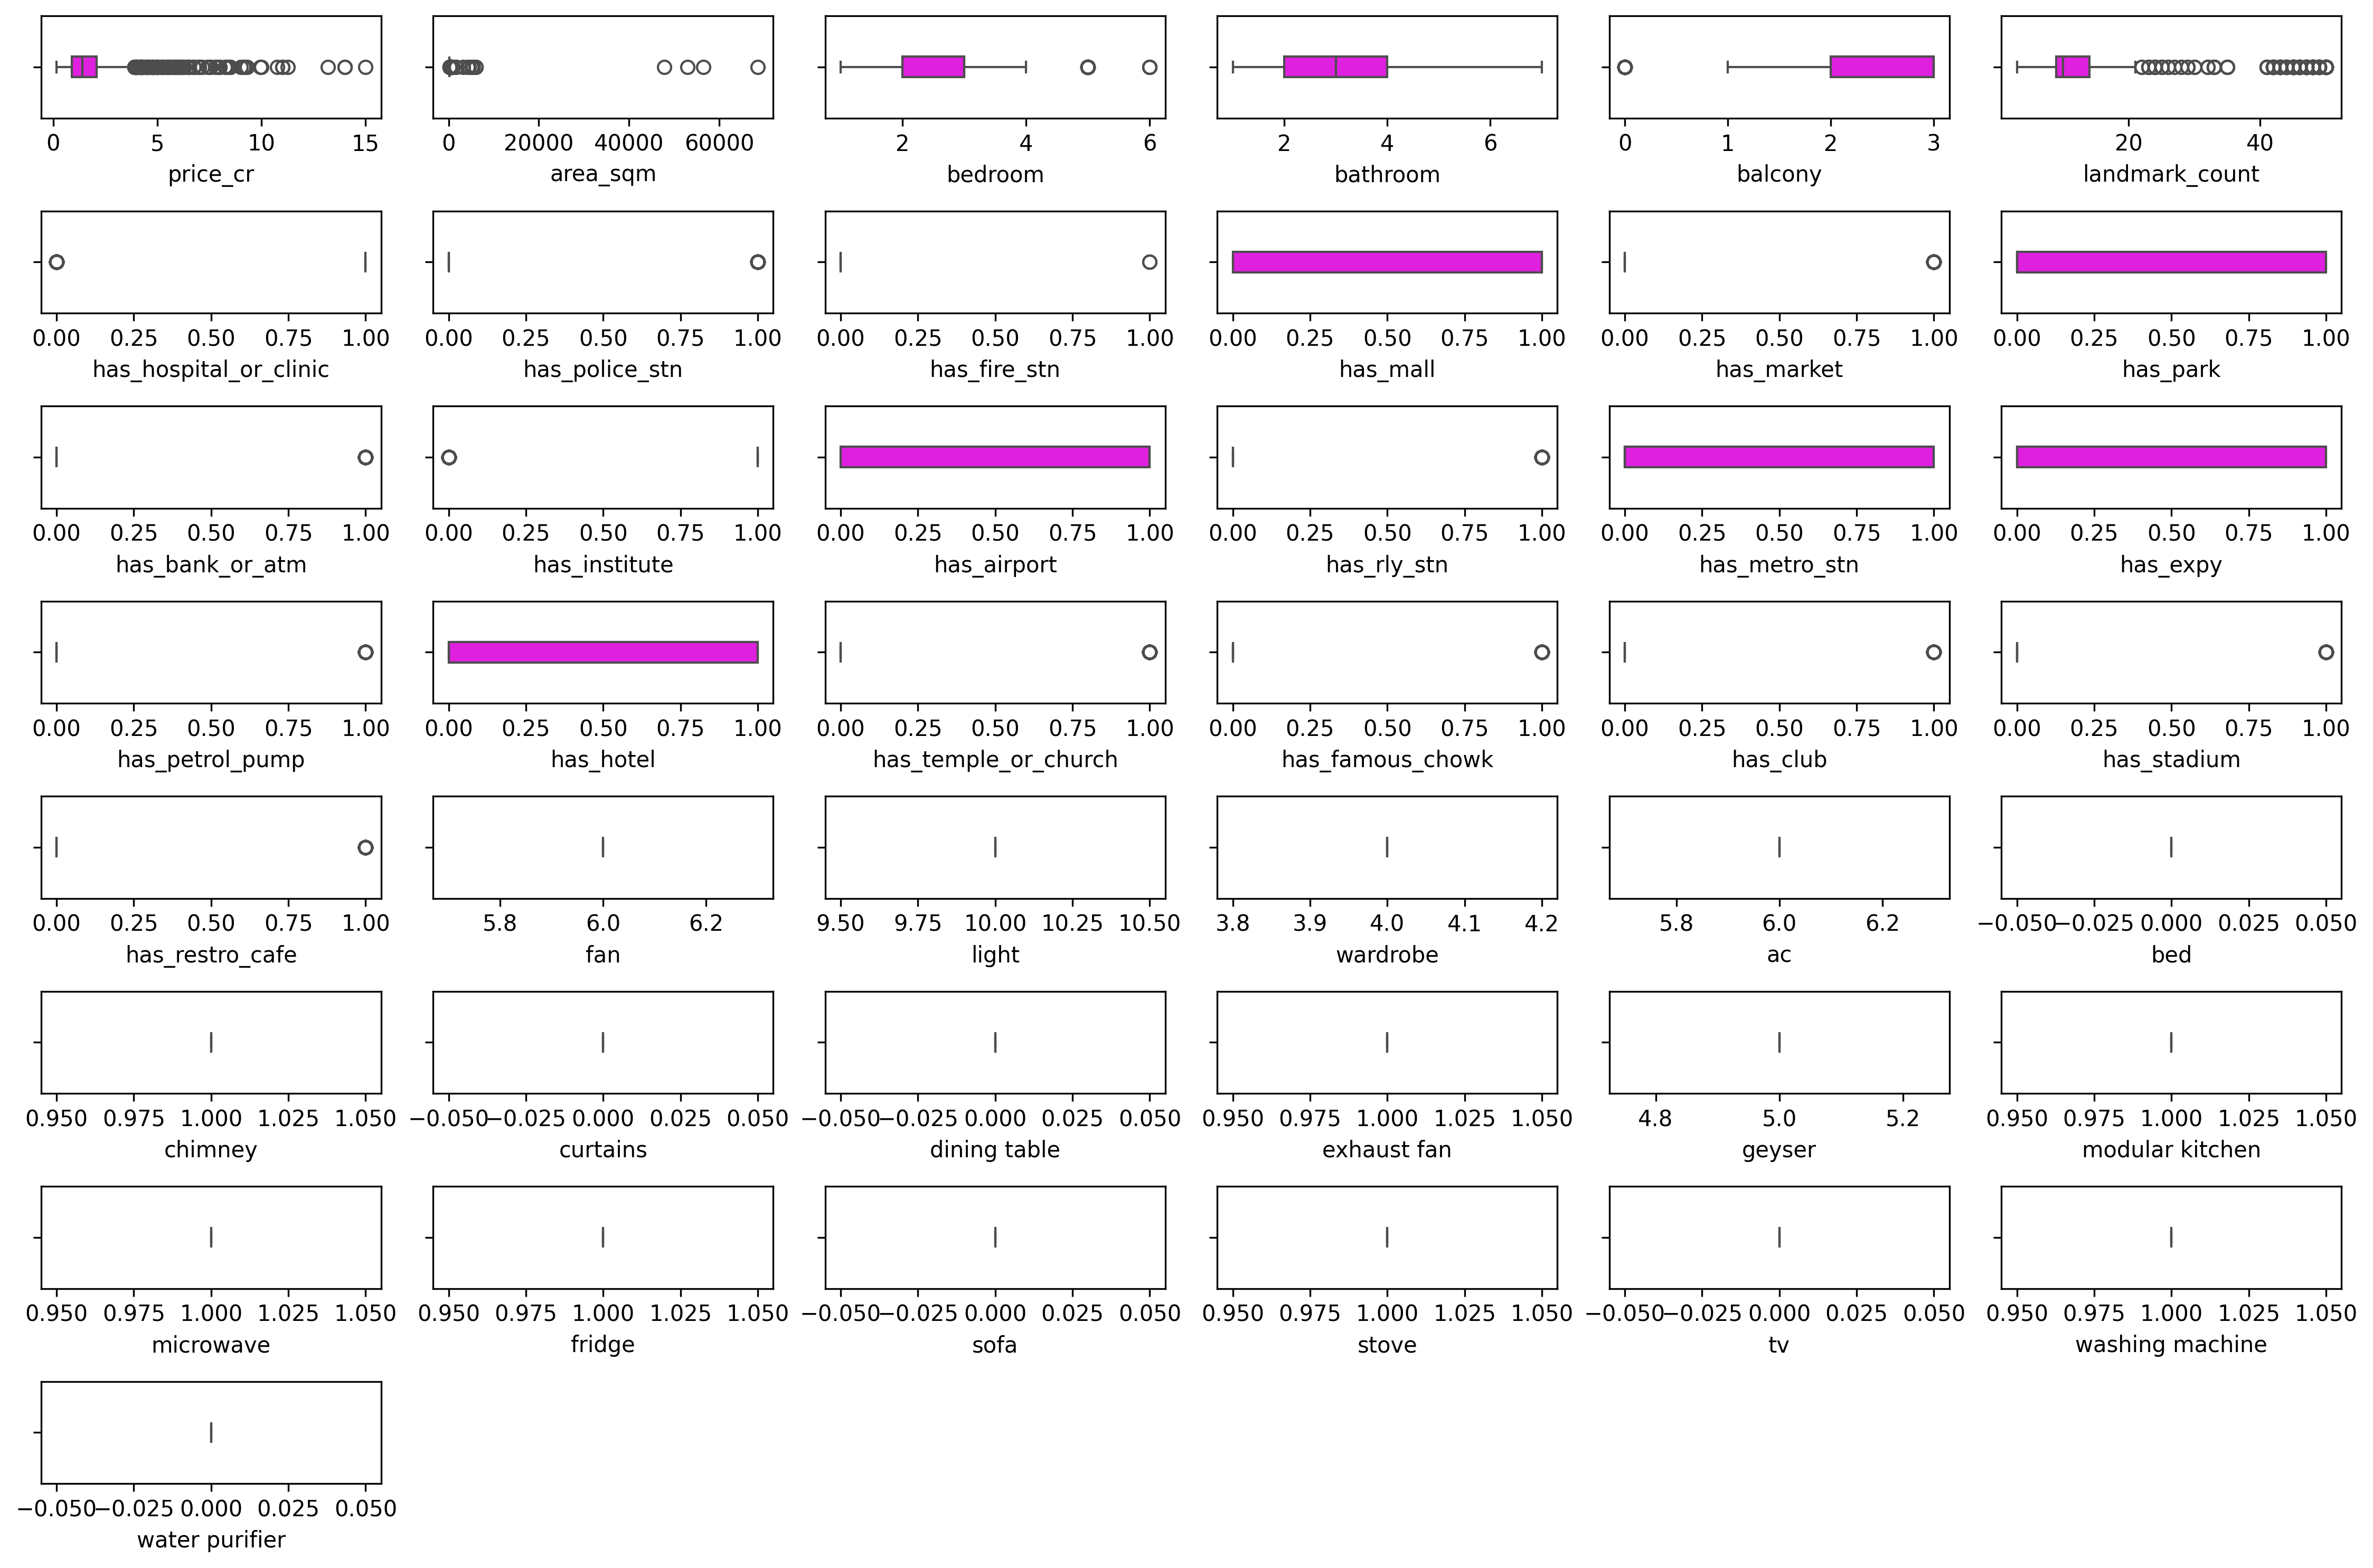

In [9]:
fig = plt.figure(figsize=(15,10),dpi=300)
i = 0
for col in ['price_cr', 'area_sqm', 'bedroom', 'bathroom', 'balcony','landmark_count', 
            'has_hospital_or_clinic', 'has_police_stn','has_fire_stn', 'has_mall', 'has_market', 
            'has_park', 'has_bank_or_atm','has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
            'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church','has_famous_chowk', 
            'has_club', 'has_stadium', 'has_restro_cafe', 'fan','light', 'wardrobe', 'ac', 'bed', 
            'chimney', 'curtains', 'dining table','exhaust fan', 'geyser', 'modular kitchen',
            'microwave', 'fridge','sofa', 'stove', 'tv', 'washing machine', 'water purifier']:
    if df[col].dtype in ('int64', 'float64'):
        i += 1
        plt.subplot(df.shape[1]//6, 6, i)
        sns.boxplot(data=df, x=col, width=0.2, color='magenta')
        plt.tight_layout()
plt.show()

In [10]:
df.shape

(2904, 50)

In [11]:
print(df['fan'].value_counts())
print(df['light'].value_counts())
print(df['wardrobe'].value_counts())
print(df['ac'].value_counts())
print(df['bed'].value_counts())
print(df['chimney'].value_counts())
print(df['curtains'].value_counts())
print(df['dining table'].value_counts())
print(df['exhaust fan'].value_counts())
print(df['geyser'].value_counts())
print(df['modular kitchen'].value_counts())
print(df['microwave'].value_counts())
print(df['fridge'].value_counts())
print(df['sofa'].value_counts())
print(df['stove'].value_counts())
print(df['tv'].value_counts())
print(df['washing machine'].value_counts())
print(df['water purifier'].value_counts())

fan
6.0    2904
Name: count, dtype: int64
light
10.0    2904
Name: count, dtype: int64
wardrobe
4.0    2904
Name: count, dtype: int64
ac
6.0    2904
Name: count, dtype: int64
bed
0.0    2904
Name: count, dtype: int64
chimney
1.0    2904
Name: count, dtype: int64
curtains
0.0    2904
Name: count, dtype: int64
dining table
0.0    2904
Name: count, dtype: int64
exhaust fan
1.0    2904
Name: count, dtype: int64
geyser
5.0    2904
Name: count, dtype: int64
modular kitchen
1.0    2904
Name: count, dtype: int64
microwave
1.0    2904
Name: count, dtype: int64
fridge
1.0    2904
Name: count, dtype: int64
sofa
0.0    2904
Name: count, dtype: int64
stove
1.0    2904
Name: count, dtype: int64
tv
0.0    2904
Name: count, dtype: int64
washing machine
1.0    2904
Name: count, dtype: int64
water purifier
0.0    2904
Name: count, dtype: int64


In [12]:
# these features contain same values for all rows:
# fan=6
# light=10
# wardrobe=4
# ac=6
# bed=0
# chimney=1
# curtains=0
# dining table=0
# exhaust fan=1
# geyser=5
# modular kitchen=1
# microwave=1
# fridge=1
# sofa=0
# stove=1
# tv=0
# washing machine=1
# water purifier=0

# therefore, these feature can be removed as they won't help the machine learn anything.

In [13]:
df.drop(columns=['fan','light','wardrobe','ac','bed','chimney','curtains','dining table',
                 'exhaust fan','geyser','modular kitchen','microwave','fridge','sofa',
                 'stove','tv','washing machine','water purifier'], 
        inplace=True)

In [14]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='str')

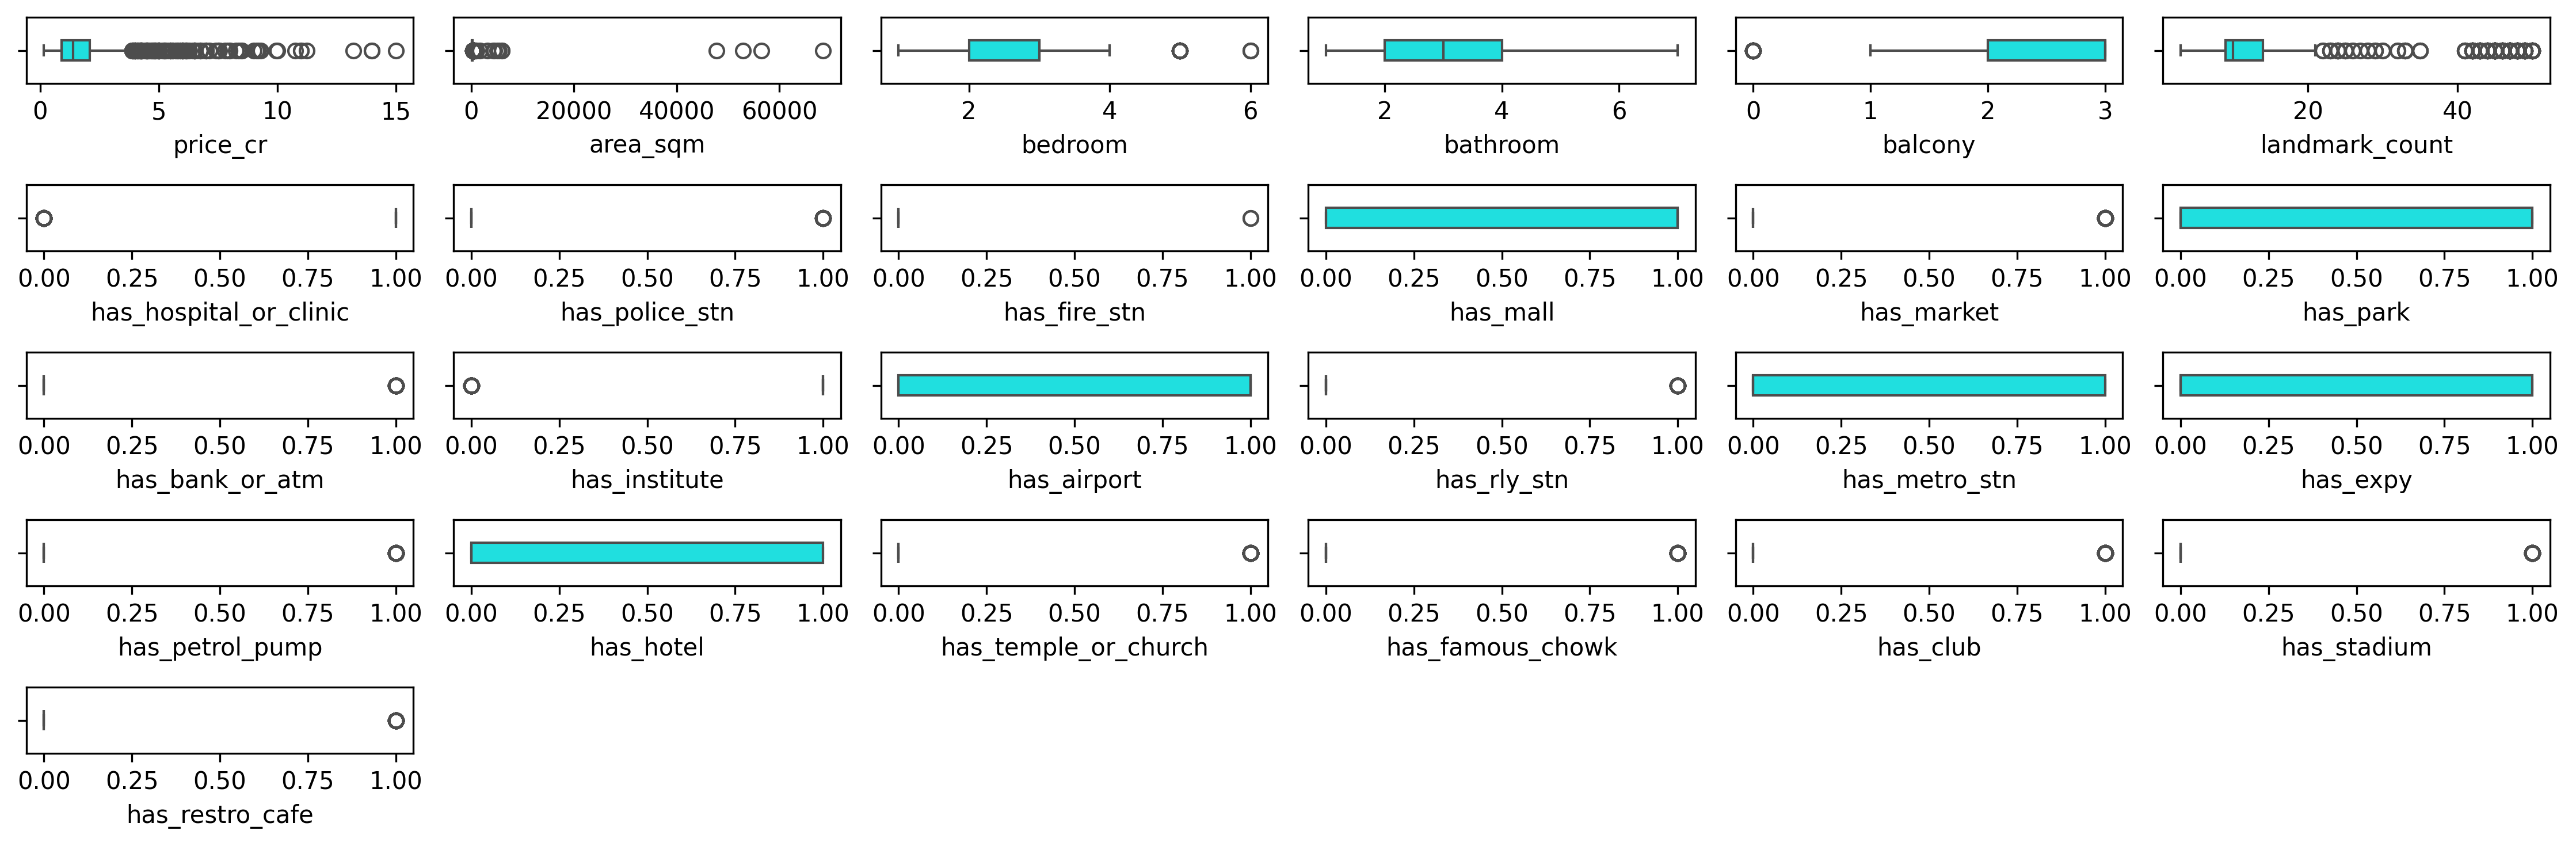

In [15]:
fig = plt.figure(figsize=(15,5),dpi=300)
i = 0
for col in ['price_cr', 'area_sqm', 'bedroom', 'bathroom', 'balcony',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe']:
    if df[col].dtype in ('int64', 'float64'):
        i += 1
        plt.subplot(df.shape[1]//6, 6, i)
        sns.boxplot(data=df, x=col, width=0.3, color='cyan')
plt.tight_layout()
plt.show()

In [16]:
df[df['area_sqm'] < 20]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
2066,6.69,1.0,1.0,0.0,1.0,sector 51,45.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,old,housing board colony,gurgaon,0.3


In [17]:
df['area_sqm'] = np.where(df['area_sqm'] < 20, 10*df['area_sqm'], df['area_sqm'])

In [18]:
df.loc[2066,'area_sqm']

np.float64(66.9)

In [19]:
df[df['area_sqm'] < 20]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr


In [20]:
df[df['area_sqm'] >10000]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
107,52884.41,2.0,2.0,2.0,0.0,sector 95,12.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the roselia,gurgaon,0.45
1283,56479.10,2.0,2.0,1.0,1.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,ramsons kshitij,gurgaon,0.31
1941,47788.95,2.0,2.0,1.0,0.0,sector 107,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature global solera 2,gurgaon,0.51
2388,68483.20,2.0,2.0,2.0,0.0,sector 33,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,built up,high,new,hcbs sports ville,sohna,0.35


In [21]:
# A 2 BHK would generally have an area of approx 60 sqm.
# so, all these area are typos. hence, dividing by 1000
df['area_sqm'] = np.where(df['area_sqm'] > 10000, df['area_sqm']/1000, df['area_sqm'])

In [22]:
df.loc[[107,1283,1941,2388],'area_sqm']

107     52.88441
1283    56.47910
1941    47.78895
2388    68.48320
Name: area_sqm, dtype: float64

In [23]:
df[df['area_sqm'] >10000]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr


In [24]:
df[df['area_sqm'] >1000]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
76,5401.48,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.46
1281,4270.38,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.24
1284,5101.96,2.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.33
1285,5984.07,3.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
1286,3195.96,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.21
1407,4534.69,1.0,1.0,2.0,1.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the serenas,sohna,0.28
1615,1021.93,4.0,4.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,carpet,high,old,m3m golfestate,gurgaon,13.20
2286,5994.94,2.0,2.0,2.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
2380,1683.59,4.0,5.0,3.0,1.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,mid aged,godrej air,gurgaon,2.50


In [25]:
#these area in sqm are also outliers, lets check them society-wise.
#the society names are:
list(df[df['area_sqm'] >1000]['society'])

['pyramid elite',
 'ramsons kshitij',
 'rof ananda',
 'rof ananda',
 'rof ananda',
 'signature the serenas',
 'm3m golfestate',
 'rof ananda',
 'godrej air']

In [26]:

df[df['society']=='pyramid elite']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
76,5401.48,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.46
104,54.01,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,mid,mid aged,pyramid elite,gurgaon,0.45
2777,53.28,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.45


In [27]:
#generally, this society has are in the range of 50-60 sqm., therefore, 5401 is an outlier.
#correcting it.
df['area_sqm'] = np.where((df['area_sqm'] > 1000) & (df['society']=='pyramid elite'), df['area_sqm']/100, df['area_sqm'])
df[df['society']=='pyramid elite']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
76,54.0148,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.46
104,54.0100,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,mid,mid aged,pyramid elite,gurgaon,0.45
2777,53.2800,2.0,2.0,1.0,0.0,sector 86,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,pyramid elite,gurgaon,0.45


In [28]:
#these area in sqm are also outliers, lets check them society-wise.
#the society names are:
list(df[df['area_sqm'] >1000]['society'])

['ramsons kshitij',
 'rof ananda',
 'rof ananda',
 'rof ananda',
 'signature the serenas',
 'm3m golfestate',
 'rof ananda',
 'godrej air']

In [29]:
df[df['society']=='ramsons kshitij']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
64,52.0300,2.0,2.0,2.0,0.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,ramsons kshitij,gurgaon,0.29
101,65.0300,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,ramsons kshitij,gurgaon,0.32
1281,4270.3800,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.24
1282,298.4000,1.0,1.0,1.0,0.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.18
1283,56.4791,2.0,2.0,1.0,1.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,ramsons kshitij,gurgaon,0.31
1622,71.2600,2.0,2.0,2.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,mid,new,ramsons kshitij,gurgaon,0.28
1986,298.4000,1.0,1.0,1.0,0.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.19
2244,59.1800,2.0,2.0,0.0,0.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,mid,under construction,ramsons kshitij,gurgaon,0.35
2420,71.2600,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,ramsons kshitij,gurgaon,0.33
2535,71.2600,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,ramsons kshitij,gurgaon,0.33


In [30]:
df.loc[1281, 'area_sqm'] /= 100
df.loc[1282, 'area_sqm'] /= 10
df.loc[1986, 'area_sqm'] /= 10
df.iloc[[1281,1282,1986]]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1281,42.7038,2.0,2.0,1.0,1.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.24
1282,29.8400,1.0,1.0,1.0,0.0,sector 95,3.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.18
1986,29.8400,1.0,1.0,1.0,0.0,sector 95,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,ramsons kshitij,gurgaon,0.19


In [31]:
#these area in sqm are also outliers, lets check them society-wise.
#the society names are:
list(df[df['area_sqm'] >1000]['society'])

['rof ananda',
 'rof ananda',
 'rof ananda',
 'signature the serenas',
 'm3m golfestate',
 'rof ananda',
 'godrej air']

In [32]:
df[df['society']=='rof ananda']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
157,35.30,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,super built up,mid,new,rof ananda,gurgaon,0.25
1132,51.02,2.0,2.0,1.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,mid,new,rof ananda,gurgaon,0.31
1284,5101.96,2.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.33
1285,5984.07,3.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
1286,3195.96,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.21
1287,34.01,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.20
1304,59.84,3.0,2.0,1.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,mid,new,rof ananda,gurgaon,0.37
1305,59.84,3.0,2.0,1.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,low,new,rof ananda,gurgaon,0.38
1306,51.02,2.0,2.0,1.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.32
1307,51.02,2.0,2.0,1.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.32


In [33]:
df.loc[1284, 'area_sqm'] /= 100
df.loc[1285, 'area_sqm'] /= 100
df.loc[1286, 'area_sqm'] /= 100
df.loc[2286, 'area_sqm'] /= 100
df.iloc[[1284,1285,1286,2286]]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1284,51.0196,2.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.33
1285,59.8407,3.0,2.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38
1286,31.9596,1.0,1.0,1.0,0.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.21
2286,59.9494,2.0,2.0,2.0,1.0,sector 95,14.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,carpet,high,new,rof ananda,gurgaon,0.38


In [34]:
#these area in sqm are also outliers, lets check them society-wise.
#the society names are:
list(df[df['area_sqm'] >1000]['society'])

['signature the serenas', 'm3m golfestate', 'godrej air']

In [35]:
df[df['society']=='signature the serenas']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
66,49.38,2.0,2.0,2.0,0.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,mid,new,signature the serenas,sohna,0.50
127,49.33,2.0,2.0,1.0,0.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,signature the serenas,sohna,0.42
1407,4534.69,1.0,1.0,2.0,1.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,new,signature the serenas,sohna,0.28
2043,49.33,2.0,2.0,1.0,0.0,sector 33,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,new,signature the serenas,sohna,0.45


In [36]:
df.loc[1407, 'area_sqm'] /= 100
df.loc[1407, 'area_sqm']

np.float64(45.3469)

In [37]:
df[df['society']=='m3m golfestate']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
22,311.69,3.0,4.0,2.0,0.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,built up,high,under construction,m3m golfestate,gurgaon,6.15
275,357.12,3.0,5.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,carpet,low,new,m3m golfestate,gurgaon,6.15
306,357.12,3.0,5.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,carpet,low,new,m3m golfestate,gurgaon,6.15
400,276.76,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,new,m3m golfestate,gurgaon,5.20
483,289.11,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,new,m3m golfestate,gurgaon,4.95
596,276.76,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,new,m3m golfestate,gurgaon,5.00
640,264.77,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,old,m3m golfestate,gurgaon,5.30
661,312.43,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,new,m3m golfestate,gurgaon,5.90
764,301.56,3.0,3.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,low,new,m3m golfestate,gurgaon,5.00
817,276.76,3.0,4.0,3.0,1.0,sector 65,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,super built up,high,old,m3m golfestate,gurgaon,5.40


In [38]:
#this property with index 1615 is not an outlier, because it is 4bhk and also its price is 13 crore.

In [39]:
df[df['society']=='godrej air']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
43,169.92000,3.0,3.0,3.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,mid aged,godrej air,gurgaon,1.83
175,83.61204,3.0,3.0,3.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,under construction,godrej air,gurgaon,1.80
287,83.61204,2.0,2.0,1.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,high,mid aged,godrej air,gurgaon,1.05
314,83.61204,2.0,2.0,1.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,high,mid aged,godrej air,gurgaon,1.05
2107,130.06000,2.0,2.0,3.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,high,under construction,godrej air,gurgaon,1.40
2315,130.06000,2.0,2.0,3.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,mid aged,godrej air,gurgaon,1.30
2380,1683.59000,4.0,5.0,3.0,1.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,mid aged,godrej air,gurgaon,2.50
2466,169.55000,3.0,3.0,2.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,high,under construction,godrej air,gurgaon,1.75
2667,197.79000,3.0,3.0,3.0,1.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,built up,high,mid aged,godrej air,gurgaon,2.60
2713,83.61204,2.0,2.0,3.0,0.0,sector 85,8.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,mid aged,godrej air,gurgaon,1.35


In [40]:
#only index 2380 is an outlier, because it is the only flat with area in 4 digits, so lets divide it by 10
df.loc[2380, 'area_sqm'] /= 10
df.loc[2380, 'area_sqm']

np.float64(168.35899999999998)

In [41]:
# lets find if there are more outliers in area
set(df[df['area_sqm'] > 500]['society'])

{'.',
 'ats triumph',
 'bestech park view grand spa',
 'central park resorts',
 'krrish provence estate',
 'm3m golfestate',
 'pioneer araya',
 'tata gurgaon gateway',
 'the penthouses at the hibiscus'}

In [42]:
df[df['society']=='.']

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1056,557.42,4.0,4.0,3.0,1.0,sector 2,27.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,super built up,mid,new,.,gurgaon,7.0


In [43]:
df[(df['society']=='ats triumph') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
702,603.87,4.0,5.0,3.0,0.0,sector 104,13.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,carpet,high,new,ats triumph,gurgaon,4.45


In [44]:
df[(df['society']=='bestech park view grand spa') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1521,643.45,4.0,4.0,3.0,1.0,sector 81,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,super built up,high,new,bestech park view grand spa,gurgaon,4.7


In [45]:
df[(df['society']=='central park resorts') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
2166,622.45,5.0,6.0,3.0,1.0,sector 48,9.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,carpet,high,new,central park resorts,gurgaon,15.0


In [46]:
df[(df['society']=='krrish provence estate') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
574,538.84,4.0,5.0,3.0,1.0,sector 2,14.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,super built up,low,new,krrish provence estate,gurgaon,5.25
657,929.03,5.0,6.0,3.0,1.0,sector 2,14.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,super built up,high,new,krrish provence estate,gurgaon,7.50
1202,538.84,4.0,5.0,3.0,1.0,sector 2,14.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,super built up,high,new,krrish provence estate,gurgaon,5.50


In [47]:
df[(df['society']=='pioneer araya') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1180,512.27,5.0,7.0,3.0,1.0,sector 62,11.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,super built up,high,new,pioneer araya,gurgaon,10.75


In [48]:
df[(df['society']=='tata gurgaon gateway') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
793,609.91,5.0,6.0,3.0,0.0,sector 113,12.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,old,tata gurgaon gateway,gurgaon,6.0


In [49]:
df[(df['society']=='the penthouses at the hibiscus') & (df['area_sqm']>500)]

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
1609,929.03,4.0,4.0,3.0,1.0,sector 50,13.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,high,old,the penthouses at the hibiscus,gurgaon,8.5
1611,836.13,4.0,3.0,3.0,1.0,sector 50,13.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,mid,old,the penthouses at the hibiscus,gurgaon,8.0


In [50]:
#all the properties with area > 500 sqm are genuine as they are luxury societies and have higher price as well.
#Let's keep all of them.

In [51]:
df['price_cr'] = df['price_cr']*1.7    #inflation adjustment for 2021 to 2026

In [52]:
df.to_csv('data/07_flats_EDA.csv', index=False)